# Автоматизированная ML-система предсказания рисков строительного проекта
## Ноутбук 2: ETL-пайплайн (Extract → Transform → Load)

**Автор:** Перминов Артем Александрович  
**Дисциплина:** Автоматизация машинного обучения

---

### Цель ноутбука
Подготовить данные для AutoML: очистка, feature engineering, кодирование и сохранение финального датасета.

### Содержание
1. [Extract — загрузка сырых данных](#1)
2. [Transform — очистка и преобразования](#2)
3. [Feature Engineering — новые признаки](#3)
4. [Кодирование категориальных признаков](#4)
5. [Контроль качества данных](#5)
6. [Load — сохранение обработанных данных](#6)
7. [Итоговый отчёт ETL](#7)

## 1. EXTRACT — Загрузка сырых данных <a id='1'></a>

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import time

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

# Пути
RAW_PATH       = Path('../data/raw/bim_ai_civil_engineering_dataset.csv')
PROCESSED_PATH = Path('../data/processed/bim_processed.csv')
TRAIN_PATH     = Path('../data/processed/train.csv')
TEST_PATH      = Path('../data/processed/test.csv')

print('Библиотеки загружены')

Библиотеки загружены


In [2]:
# ── EXTRACT ────────────────────────────────────────────────
t0 = time.time()

df_raw = pd.read_csv(RAW_PATH, parse_dates=['Start_Date', 'End_Date'])

print(f'Загружено за {time.time()-t0:.2f} сек')
print(f'   Строк    : {df_raw.shape[0]:,}')
print(f'   Столбцов : {df_raw.shape[1]}')
print(f'   Память   : {df_raw.memory_usage(deep=True).sum() / 1024:.1f} KB')
print()
print('Первые 3 строки:')
df_raw.head(3)

Загружено за 0.01 сек
   Строк    : 1,000
   Столбцов : 28
   Память   : 487.7 KB

Первые 3 строки:


,Project_ID,Project_Type,Location,Start_Date,End_Date,Planned_Cost,Actual_Cost,Cost_Overrun,Planned_Duration,Actual_Duration,...,Energy_Consumption,Material_Usage,Labor_Hours,Equipment_Utilization,Accident_Count,Safety_Risk_Score,Image_Analysis_Score,Anomaly_Detected,Completion_Percentage,Risk_Level
0,PJT_1,Tunnel,Houston,2020-01-01,2021-09-26,12260784,1.505450e+07,2.793720e+06,699,813.914852,...,25202.994687,244.843310,6602,76.300184,8,6.192198,52.988330,0,95.006343,High
1,PJT_2,Dam,Houston,2020-01-02,2020-12-06,2369277,3.507054e+06,1.137777e+06,269,384.118221,...,49066.172542,263.123025,7121,63.527671,5,2.134473,50.885745,0,25.294824,Low
2,PJT_3,Building,Houston,2020-01-03,2021-12-05,23299783,2.169213e+07,-1.607656e+06,899,1081.777915,...,48192.547163,608.985023,9956,47.099444,2,3.113728,93.905836,0,97.478830,Medium


## 2. TRANSFORM — Очистка и базовые преобразования <a id='2'></a>

In [3]:
df = df_raw.copy()

# ── 2.1 Проверка пропусков ─────────────────────────────────
missing = df.isnull().sum()
if missing.sum() == 0:
    print('Пропущенных значений нет')
else:
    print('Обнаружены пропуски:')
    print(missing[missing > 0])

# ── 2.2 Проверка дубликатов ───────────────────────────────
dupes = df.duplicated().sum()
if dupes == 0:
    print('Дубликатов нет')
else:
    print(f'Найдено {dupes} дубликатов — удаляем')
    df = df.drop_duplicates()

# ── 2.3 Удаление ненужных столбцов ───────────────────────
cols_to_drop = ['Project_ID']   # идентификатор, не несёт информации
df = df.drop(columns=cols_to_drop)
print(f'\nУдалены столбцы: {cols_to_drop}')

Пропущенных значений нет
Дубликатов нет

Удалены столбцы: ['Project_ID']


In [4]:
# ── 2.4 Проверка выбросов (IQR метод) ────────────────────
num_cols = df.select_dtypes(include='number').columns.tolist()

outlier_report = {}
for col in num_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    if n_out > 0:
        outlier_report[col] = n_out

if outlier_report:
    print('Выбросы (IQR метод):')
    for col, n in sorted(outlier_report.items(), key=lambda x: -x[1]):
        print(f'   {col:35s}: {n:4d} ({n/len(df)*100:.1f}%)')
    print('\n   Выбросы оставляем — PyCaret обработает их через remove_outliers=True')
else:
    print('Выбросов не обнаружено')

Выбросы (IQR метод):
   Anomaly_Detected                   :  197 (19.7%)
   Cost_Overrun                       :   11 (1.1%)
   Schedule_Deviation                 :    8 (0.8%)

   Выбросы оставляем — PyCaret обработает их через remove_outliers=True


## 3. Feature Engineering — Создание новых признаков <a id='3'></a>

In [5]:
print('Feature Engineering')
fe_log = []

# ── 3.1 Признаки из дат ───────────────────────────────────
df['Project_Duration_Days'] = (df['End_Date'] - df['Start_Date']).dt.days
fe_log.append('Project_Duration_Days = End_Date - Start_Date')

df['Start_Year']  = df['Start_Date'].dt.year
df['Start_Month'] = df['Start_Date'].dt.month
df['Start_Quarter'] = df['Start_Date'].dt.quarter
fe_log.append('Start_Year, Start_Month, Start_Quarter')

# Удаляем исходные столбцы дат (заменены числовыми)
df = df.drop(columns=['Start_Date', 'End_Date'])
fe_log.append('Удалены Start_Date, End_Date → заменены числовыми признаками')

# ── 3.2 Финансовые признаки ───────────────────────────────
df['Cost_Overrun_Pct'] = (df['Cost_Overrun'] / df['Planned_Cost'] * 100).round(4)
fe_log.append('Cost_Overrun_Pct = Cost_Overrun / Planned_Cost * 100')

df['Cost_Efficiency'] = (df['Planned_Cost'] / df['Actual_Cost']).round(4)
fe_log.append('Cost_Efficiency = Planned_Cost / Actual_Cost (>1 = экономия, <1 = перерасход)')

# ── 3.3 Временные признаки ───────────────────────────────
df['Schedule_Overrun_Pct'] = (df['Schedule_Deviation'] / df['Planned_Duration'] * 100).round(4)
fe_log.append('Schedule_Overrun_Pct = Schedule_Deviation / Planned_Duration * 100')

df['Duration_Efficiency'] = (df['Planned_Duration'] / df['Actual_Duration']).round(4)
fe_log.append('Duration_Efficiency = Planned_Duration / Actual_Duration')

# ── 3.4 Признак риска на основе аномалий ─────────────────
df['Anomaly_Detected'] = df['Anomaly_Detected'].astype(int)
fe_log.append('Anomaly_Detected: bool → int (0/1)')

# ── 3.5 Composite Risk Indicator ─────────────────────────
df['Risk_Composite'] = (
    df['Cost_Overrun_Pct'].clip(0) * 0.3 +
    df['Schedule_Overrun_Pct'].clip(0) * 0.3 +
    df['Safety_Risk_Score'] * 0.2 +
    df['Accident_Count'] * 0.2
).round(4)
fe_log.append('Risk_Composite = взвешенная сумма ключевых риск-факторов')

print(f'Создано/изменено {len(fe_log)} признаков:')
for i, log in enumerate(fe_log, 1):
    print(f'   {i}. {log}')

Feature Engineering
Создано/изменено 9 признаков:
   1. Project_Duration_Days = End_Date - Start_Date
   2. Start_Year, Start_Month, Start_Quarter
   3. Удалены Start_Date, End_Date → заменены числовыми признаками
   4. Cost_Overrun_Pct = Cost_Overrun / Planned_Cost * 100
   5. Cost_Efficiency = Planned_Cost / Actual_Cost (>1 = экономия, <1 = перерасход)
   6. Schedule_Overrun_Pct = Schedule_Deviation / Planned_Duration * 100
   7. Duration_Efficiency = Planned_Duration / Actual_Duration
   8. Anomaly_Detected: bool → int (0/1)
   9. Risk_Composite = взвешенная сумма ключевых риск-факторов


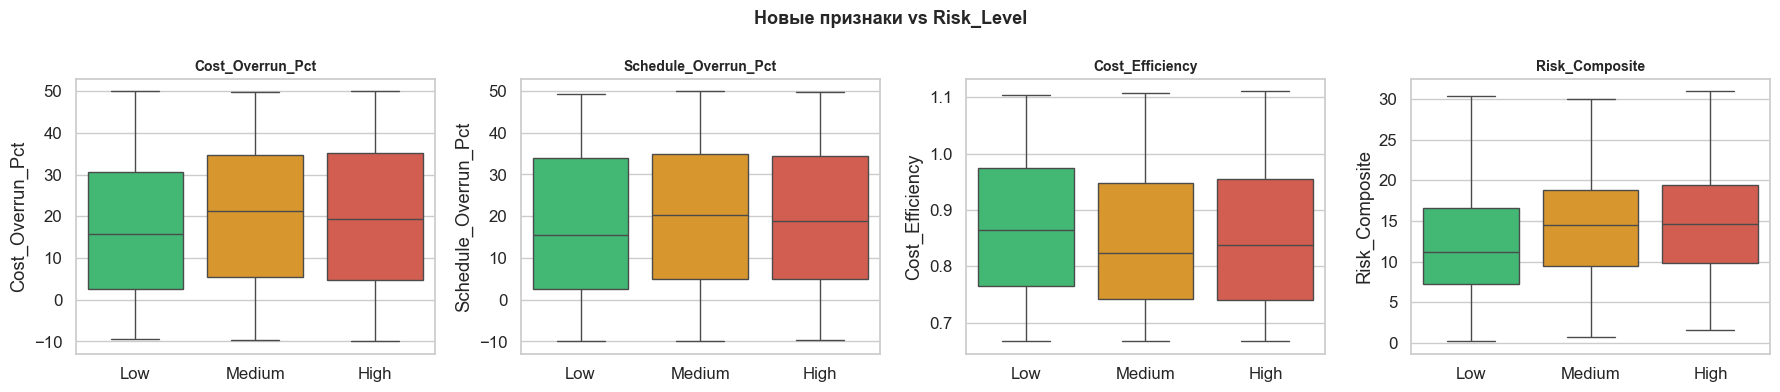

In [6]:
# Визуализация новых признаков
RISK_COLORS = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
RISK_ORDER  = ['Low', 'Medium', 'High']

new_features = ['Cost_Overrun_Pct', 'Schedule_Overrun_Pct', 
                'Cost_Efficiency', 'Risk_Composite']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, new_features):
    sns.boxplot(data=df, x='Risk_Level', y=col,
                order=RISK_ORDER, palette=RISK_COLORS, ax=ax)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Новые признаки vs Risk_Level', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/07_new_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Кодирование категориальных признаков <a id='4'></a>

In [7]:
# PyCaret автоматически кодирует категориальные признаки
# Но целевую переменную приведём к порядковому виду для удобства

cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Категориальные признаки (PyCaret закодирует автоматически):')
for col in cat_cols:
    vals = df[col].unique().tolist()
    print(f'   {col:25s}: {vals}')

print()
print('Целевая переменная Risk_Level оставлена как строка')
print('   PyCaret принимает строковые метки классов напрямую')

Категориальные признаки (PyCaret закодирует автоматически):
   Project_Type             : ['Tunnel', 'Dam', 'Building', 'Road', 'Bridge']
   Location                 : ['Houston', 'Seattle', 'Los Angeles', 'New York', 'Chicago']
   Weather_Condition        : ['Snowy', 'Cloudy', 'Sunny', 'Rainy', 'Stormy']
   Risk_Level               : ['High', 'Low', 'Medium']

Целевая переменная Risk_Level оставлена как строка
   PyCaret принимает строковые метки классов напрямую


## 5. Контроль качества данных <a id='5'></a>

In [8]:
print('🔍 КОНТРОЛЬ КАЧЕСТВА ПОСЛЕ ТРАНСФОРМАЦИИ')
print('=' * 55)

# Базовые проверки
checks = {
    'Пропущенных значений': df.isnull().sum().sum(),
    'Дубликатов строк':     df.duplicated().sum(),
    'Бесконечных значений': np.isinf(df.select_dtypes('number')).sum().sum(),
}

all_ok = True
for check, val in checks.items():
    status = '✅' if val == 0 else '❌'
    print(f'   {status} {check}: {val}')
    if val > 0:
        all_ok = False

# Проверка целевой переменной
target_vals = df['Risk_Level'].unique()
expected    = {'Low', 'Medium', 'High'}
if set(target_vals) == expected:
    print(f'   ✅ Risk_Level содержит ровно 3 класса: {sorted(target_vals)}')
else:
    print(f'   ❌ Неожиданные классы: {target_vals}')
    all_ok = False

# Итоговый размер
print()
print(f'Итоговый датасет: {df.shape[0]} строк × {df.shape[1]} столбцов')
print(f'   Числовых признаков    : {df.select_dtypes("number").shape[1]}')
print(f'   Категориальных признаков: {df.select_dtypes("object").shape[1]}')
print()
if all_ok:
    print('Все проверки пройдены — данные готовы к обучению')
else:
    print('Проблемы')

🔍 КОНТРОЛЬ КАЧЕСТВА ПОСЛЕ ТРАНСФОРМАЦИИ
   ✅ Пропущенных значений: 0
   ✅ Дубликатов строк: 0
   ✅ Бесконечных значений: 0
   ✅ Risk_Level содержит ровно 3 класса: ['High', 'Low', 'Medium']

Итоговый датасет: 1000 строк × 34 столбцов
   Числовых признаков    : 30
   Категориальных признаков: 4

Все проверки пройдены — данные готовы к обучению


In [9]:
# Финальный список признаков
feature_info = pd.DataFrame({
    'Тип':        df.dtypes,
    'Уникальных': df.nunique(),
    'Мин':        df.select_dtypes('number').min().reindex(df.columns),
    'Макс':       df.select_dtypes('number').max().reindex(df.columns),
})

print('Финальный список признаков:')
display(feature_info)

Финальный список признаков:


,Тип,Уникальных,Мин,Макс
Project_Type,object,5,NaN,NaN
Location,object,5,NaN,NaN
Planned_Cost,int64,1000,1.045475e+06,4.996854e+07
Actual_Cost,float64,1000,1.180252e+06,7.251939e+07
Cost_Overrun,float64,1000,-4.648579e+06,2.401229e+07
Planned_Duration,int64,546,1.800000e+02,8.990000e+02
Actual_Duration,float64,1000,1.652782e+02,1.340353e+03
Schedule_Deviation,float64,1000,-7.913649e+01,4.463525e+02
Vibration_Level,float64,1000,1.074449e-01,1.998975e+00
Crack_Width,float64,1000,1.205023e-03,4.996036e+00


## 6. LOAD — Разбивка и сохранение данных <a id='6'></a>

In [10]:
from sklearn.model_selection import train_test_split

# ── Разбивка train / test (80/20, стратификация по классам) ──
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['Risk_Level']
)

print(f'Разбивка данных (80/20, stratified):')
print(f'   Train: {len(train_df):,} строк')
print(f'   Test : {len(test_df):,} строк')

# Проверка сохранения пропорций классов
print()
print('Распределение классов после разбивки:')
compare = pd.DataFrame({
    'Весь датасет': df['Risk_Level'].value_counts(normalize=True).mul(100).round(1),
    'Train':        train_df['Risk_Level'].value_counts(normalize=True).mul(100).round(1),
    'Test':         test_df['Risk_Level'].value_counts(normalize=True).mul(100).round(1),
}).loc[['High', 'Medium', 'Low']]
compare.columns = ['Весь датасет %', 'Train %', 'Test %']
print(compare.to_string())

Разбивка данных (80/20, stratified):
   Train: 800 строк
   Test : 200 строк

Распределение классов после разбивки:
            Весь датасет %  Train %  Test %
Risk_Level                                 
High                  50.2     50.1    50.5
Medium                34.2     34.2    34.0
Low                   15.6     15.6    15.5


In [11]:
# ── LOAD — Сохранение ─────────────────────────────────────
t_save = time.time()

df.to_csv(PROCESSED_PATH, index=False)
train_df.to_csv(TRAIN_PATH, index=False)
test_df.to_csv(TEST_PATH,   index=False)

elapsed = time.time() - t_save

print(f'Данные сохранены за {elapsed:.2f} сек:')
print(f'   {PROCESSED_PATH}  ({PROCESSED_PATH.stat().st_size//1024} KB)')
print(f'   {TRAIN_PATH}       ({TRAIN_PATH.stat().st_size//1024} KB)')
print(f'   {TEST_PATH}        ({TEST_PATH.stat().st_size//1024} KB)')

Данные сохранены за 0.02 сек:
   ../data/processed/bim_processed.csv  (368 KB)
   ../data/processed/train.csv       (294 KB)
   ../data/processed/test.csv        (74 KB)


## 7. Итоговый отчёт ETL <a id='7'></a>

In [12]:
print('=' * 60)
print('ИТОГОВЫЙ ОТЧЁТ ETL-ПАЙПЛАЙНА')
print('=' * 60)
print(f'''
── EXTRACT ──────────────────────────────────────
  Источник : {RAW_PATH.name}
  Загружено: {df_raw.shape[0]} строк × {df_raw.shape[1]} столбцов

── TRANSFORM ────────────────────────────────────
  Удалено столбцов    : 3 (Project_ID, Start_Date, End_Date)
  Создано признаков   : 8
    • Project_Duration_Days  — длительность в днях
    • Start_Year             — год начала
    • Start_Month            — месяц начала
    • Start_Quarter          — квартал начала
    • Cost_Overrun_Pct       — % перерасхода бюджета
    • Cost_Efficiency        — коэф. эффективности затрат
    • Schedule_Overrun_Pct   — % нарушения сроков
    • Duration_Efficiency    — коэф. эффективности сроков
    • Risk_Composite         — составной индикатор риска
  Пропуски            : 0
  Дубликаты           : 0

── LOAD ─────────────────────────────────────────
  Финальный датасет   : {df.shape[0]} строк × {df.shape[1]} столбцов
  Train               : {len(train_df)} строк (80%)
  Test                : {len(test_df)} строк (20%)
  Стратификация       : (пропорции классов сохранены)
''')
print('=' * 60)
print('ETL завершён. Следующий шаг: 03_AutoML.ipynb')

ИТОГОВЫЙ ОТЧЁТ ETL-ПАЙПЛАЙНА

── EXTRACT ──────────────────────────────────────
  Источник : bim_ai_civil_engineering_dataset.csv
  Загружено: 1000 строк × 28 столбцов

── TRANSFORM ────────────────────────────────────
  Удалено столбцов    : 3 (Project_ID, Start_Date, End_Date)
  Создано признаков   : 8
    • Project_Duration_Days  — длительность в днях
    • Start_Year             — год начала
    • Start_Month            — месяц начала
    • Start_Quarter          — квартал начала
    • Cost_Overrun_Pct       — % перерасхода бюджета
    • Cost_Efficiency        — коэф. эффективности затрат
    • Schedule_Overrun_Pct   — % нарушения сроков
    • Duration_Efficiency    — коэф. эффективности сроков
    • Risk_Composite         — составной индикатор риска
  Пропуски            : 0
  Дубликаты           : 0

── LOAD ─────────────────────────────────────────
  Финальный датасет   : 1000 строк × 34 столбцов
  Train               : 800 строк (80%)
  Test                : 200 строк (20%)
  С